In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mnLa683Yzcd07PEOtSdC")
project = rf.workspace("blue-halo").project("vegetation-segmentation")
version = project.version(4)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vegetation-segmentation-4 in yolov8:: 100%|██████████| 2148/2148 [00:03<00:00, 631.66it/s] 


In [ ]:
import os
import random
import numpy as np
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
# 1. PATH TO VEGETATION DATASET
VEG_DATASET = "vegetation-segmentation-4"

def find_images(folder):
    """Return all image paths in folder."""
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(root, f))
    return paths
print(" Scanning vegetation dataset...")
images = find_images(VEG_DATASET)
print(f"Total vegetation images found: {len(images)}")
if len(images) == 0:
    print(" No vegetation images found. Check the folder name.")
    exit()
# 2. OUTPUT FOLDERS
os.makedirs("processed/train", exist_ok=True)
os.makedirs("processed/test", exist_ok=True)
os.makedirs("processed/augmented", exist_ok=True)
os.makedirs("processed/encoded_pixels", exist_ok=True)
# 3. PREPROCESSING + AUGMENTATION
resize = transforms.Resize((512, 512))

augment = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((512, 512))
])
# 4. TRAIN–TEST SPLIT
random.shuffle(images)
split = int(0.8 * len(images))
train = images[:split]
test = images[split:]
print(f"Training images: {len(train)}")
print(f"Testing images: {len(test)}")
# 5. FUNCTION TO PROCESS IMAGE
def process_image(img_path, save_folder, do_aug=False):
    img = Image.open(img_path).convert("RGB")
    # A) Resize
    resized = resize(img)
    resized.save(os.path.join(save_folder, os.path.basename(img_path)))
    # B) Augmentation (only on train)
    if do_aug:
        aug_img = augment(img)
        aug_img.save(f"processed/augmented/AUG_{os.path.basename(img_path)}")
    # C) Encoding – extract center pixel (RGB)
    arr = np.array(resized)
    h, w, _ = arr.shape
    center_pixel = arr[h//2, w//2]      # shape (3,) → [R,G,B]
    # Save encoding
    pixel_file = f"processed/encoded_pixels/{os.path.basename(img_path)}.txt"
    np.savetxt(pixel_file, center_pixel.reshape(1, 3), fmt='%d')
# 6. PROCESS TRAIN IMAGES
print("\n Processing training images...")
for img in tqdm(train):
    process_image(img, "processed/train", do_aug=True)
# 7. PROCESS TEST IMAGES
print("\n Processing test images...")
for img in tqdm(test):
    process_image(img, "processed/test", do_aug=False)
# DONE
print("\n PREPROCESSING COMPLETE (VEGETATION ONLY)")
print(" Processed images → processed/train , processed/test")
print(" Augmented images → processed/augmented")
print(" Encoded RGB pixels → processed/encoded_pixels")

 Scanning vegetation dataset...
Total vegetation images found: 1068
Training images: 854
Testing images: 214

 Processing training images...


100%|██████████| 854/854 [01:06<00:00, 12.90it/s]



 Processing test images...


100%|██████████| 214/214 [00:05<00:00, 39.02it/s]


 PREPROCESSING COMPLETE (VEGETATION ONLY)
 Processed images → processed/train , processed/test
 Augmented images → processed/augmented
 Encoded RGB pixels → processed/encoded_pixels


**Section-3**

**8. Process Train & Test Images**

> Loop over all images to apply processing.

**9. Visualization of Annotations**

> Visualize YOLO calculate vegetation % coverage, overlay on images


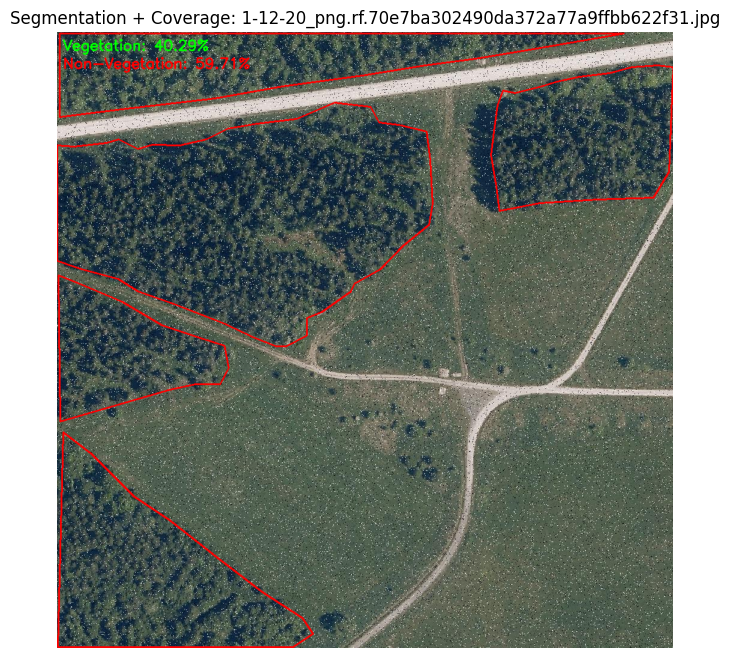

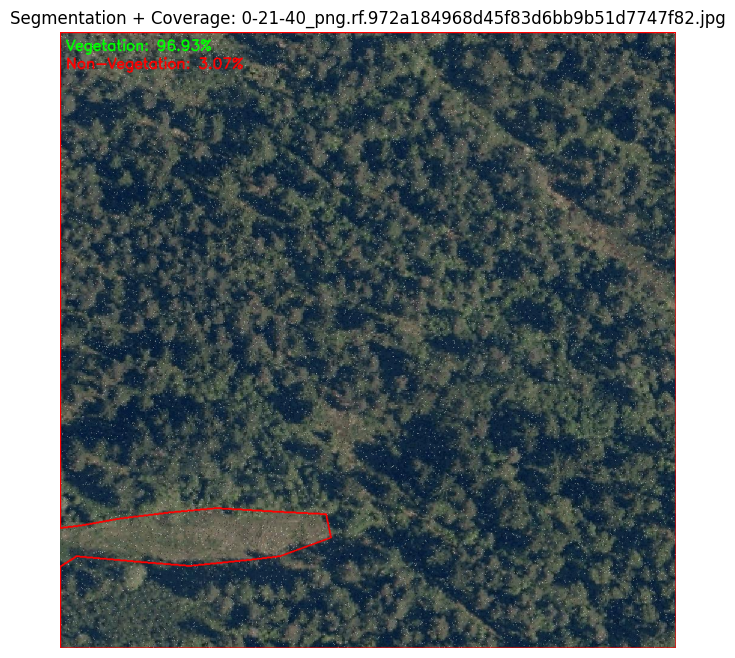

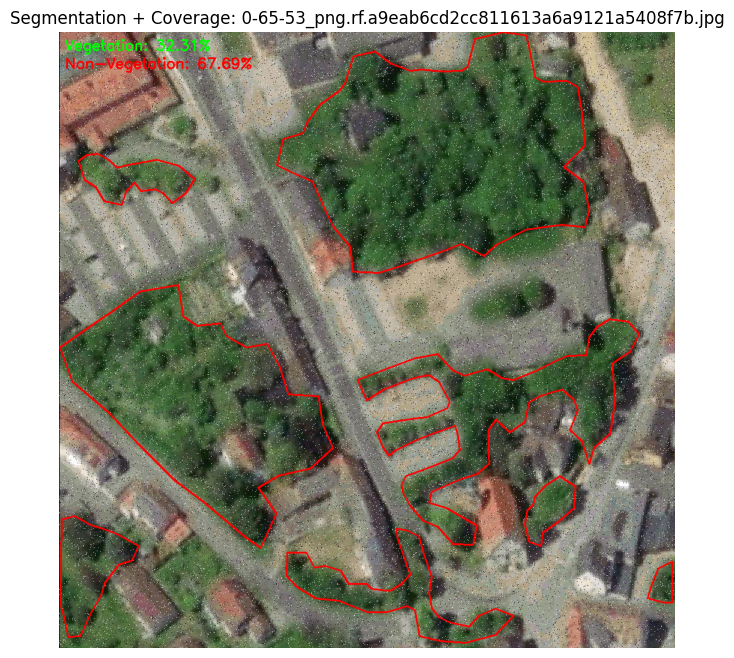

Vegetation coverage displayed successfully!


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

dataset_path = '/content/vegetation-segmentation-4'
image_dir = os.path.join(dataset_path, 'train', 'images')
label_dir = os.path.join(dataset_path, 'train', 'labels')

image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
sample_image_files = image_files[:3]
class_names = ['vegetation']

def parse_yolo_segmentation(label_path, img_width, img_height):
    polygons = []
    if not os.path.exists(label_path):
        return polygons
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            if len(coords) % 2 != 0:
                continue
            polygon = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * img_width)
                y = int(coords[i + 1] * img_height)
                polygon.append((x, y))
            polygons.append({
                'class_id': class_id,
                'polygon': polygon
            })
    return polygons

for img_file in sample_image_files:
    img_path = os.path.join(image_dir, img_file)
    label_file = os.path.splitext(img_file)[0] + '.txt'
    label_path = os.path.join(label_dir, label_file)

    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ = img_rgb.shape

    annotations = parse_yolo_segmentation(label_path, img_width, img_height)

    vegetation_mask = np.zeros((img_height, img_width), dtype=np.uint8)

    for ann in annotations:
        polygon = ann['polygon']
        pts = np.array(polygon, np.int32)

        # Draw only polygon outline (free style)
        cv2.polylines(img_rgb, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        # Fill mask for area calculation
        cv2.fillPoly(vegetation_mask, [pts], 255)

    # Calculate vegetation %
    veg_pixels = np.sum(vegetation_mask == 255)
    total_pixels = img_height * img_width
    veg_percentage = (veg_pixels / total_pixels) * 100
    nonveg_percentage = 100 - veg_percentage

    # Put percentage on image
    cv2.putText(img_rgb,
                f"Vegetation: {veg_percentage:.2f}%",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0, 255, 0), 2)

    cv2.putText(img_rgb,
                f"Non-Vegetation: {nonveg_percentage:.2f}%",
                (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255, 0, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f"Segmentation + Coverage: {img_file}")
    plt.axis('off')
    plt.show()

print("Vegetation coverage displayed successfully!")


In [ ]:
train_label_files = os.listdir("/content/processed/train")
test_label_files = os.listdir("/content/processed/test")
aug=os.listdir("/content/processed/augmented")
train=os.listdir("/content/vegetation-segmentation-4/train/images")
print(len(train))
print("Augmented images:", len(aug))
print("Train labels:", len(train_label_files))
print("Test labels:", len(test_label_files))


945
Augmented images: 854
Train labels: 854
Test labels: 214


In [ ]:
import os
import numpy as np
from PIL import Image
from shapely.geometry import Polygon
from shapely.affinity import scale

def yolo_seg_to_mask(image_dir, label_dir, mask_dir, img_size=(256, 256)):
    os.makedirs(mask_dir, exist_ok=True)
    images = os.listdir(image_dir)

    for img_name in images:
        img_path = os.path.join(image_dir, img_name)
        lbl_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))
        mask_path = os.path.join(mask_dir, img_name.replace(".jpg", ".png"))

        img = Image.open(img_path)
        orig_w, orig_h = img.size
        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

        if os.path.exists(lbl_path):
            with open(lbl_path, "r") as f:
                for line in f.readlines():
                    values = list(map(float, line.strip().split()))
                    cls = int(values[0])
                    coords = values[1:]

                    # coords are normalized between 0-1
                    coords = [(coords[i]*orig_w, coords[i+1]*orig_h) for i in range(0, len(coords), 2)]

                    poly = Polygon(coords)
                    x, y = np.meshgrid(np.arange(orig_w), np.arange(orig_h))
                    x, y = x.flatten(), y.flatten()
                    points = np.vstack((x, y)).T

                    mask_flat = np.array([poly.contains(Point(pt)) for pt in points])
                    mask += mask_flat.reshape(orig_h, orig_w).astype(np.uint8)

        mask = np.clip(mask, 0, 1)  # ensure binary
        mask = np.array(Image.fromarray(mask).resize(img_size, resample=Image.NEAREST))
        Image.fromarray(mask).save(mask_path)


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

img_dir = "/content/vegetation-segmentation-4/train/images"
mask_dir = "/content/vegetation-segmentation-4/train/masks"

img_name = os.listdir(img_dir)[0]

img_path = os.path.join(img_dir, img_name)

# mask has SAME NAME, just lives in masks folder
mask_path = os.path.join(mask_dir, img_name)

print("Image:", img_path)
print("Mask:", mask_path)

img = Image.open(img_path)
mask = Image.open(mask_path)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()


Image: /content/vegetation-segmentation-4/train/images/1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg
Mask: /content/vegetation-segmentation-4/train/masks/1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg


FileNotFoundError: [Errno 2] No such file or directory: '/content/vegetation-segmentation-4/train/masks/1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg'

In [ ]:
import os

mask_dir = "/content/vegetation-segmentation-4/train/masks"
print("Number of masks:", len(os.listdir(mask_dir)))
print("First 10 mask files:", os.listdir(mask_dir)[:10])


Number of masks: 1
First 10 mask files: ['.ipynb_checkpoints']


In [ ]:
import os

print("Images:")
print(os.listdir("/content/vegetation-segmentation-4/train/images")[:5])

print("\nLabels:")
print(os.listdir("/content/vegetation-segmentation-4/train/labels")[:5])


Images:
['1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg', '0-21-40_png.rf.972a184968d45f83d6bb9b51d7747f82.jpg', '0-65-53_png.rf.a9eab6cd2cc811613a6a9121a5408f7b.jpg', '0-21-14_png.rf.df13a2d9db898c05b706f1725e3c0195.jpg', '0-8-23_png.rf.441acaa11151ba65d3e8aa737ebe6b87.jpg']

Labels:
['0-9-42_png.rf.5437bf2d69a6a9f031dd84424f0d3b62.txt', '0-22-49_png.rf.30e57f12673509eecf46987758f4060f.txt', '0-39-38_png.rf.486016ef8c9ee403713c1b8375c74c7f.txt', '0-41-30_png.rf.4e10bc9c182d8ca012af024540d5ce00.txt', '0-25-47_png.rf.fe3c3128af573cea5a8379b325aa194c.txt']


In [ ]:
img_name = os.listdir("/content/vegetation-segmentation-4/train/images")[0]
label_name = os.path.splitext(img_name)[0] + ".txt"

print("Image:", img_name)
print("Expected label:", label_name)

label_path = f"/content/vegetation-segmentation-4/train/labels/{label_name}"
print("Label exists?", os.path.exists(label_path))


Image: 1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg
Expected label: 1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.txt
Label exists? True


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

def yolo_seg_to_mask(image_dir, label_dir, mask_dir):
    os.makedirs(mask_dir, exist_ok=True)

    label_files = {os.path.splitext(f)[0]: f for f in os.listdir(label_dir)}

    for img_name in os.listdir(image_dir):
        img_base = os.path.splitext(img_name)[0]

        if img_base not in label_files:
            continue  # skip images without labels

        img_path = os.path.join(image_dir, img_name)
        lbl_path = os.path.join(label_dir, label_files[img_base])
        mask_path = os.path.join(mask_dir, img_name)

        img = Image.open(img_path)
        w, h = img.size
        mask = np.zeros((h, w), dtype=np.uint8)

        with open(lbl_path) as f:
            for line in f:
                data = list(map(float, line.strip().split()))
                coords = data[1:]

                pts = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                if len(pts) > 2:
                    cv2.fillPoly(mask, [np.array(pts, np.int32)], 1)

        Image.fromarray(mask).save(mask_path)

# RUN
yolo_seg_to_mask(
    "/content/vegetation-segmentation-4/train/images",
    "/content/vegetation-segmentation-4/train/labels",
    "/content/vegetation-segmentation-4/train/masks"
)

yolo_seg_to_mask(
    "/content/vegetation-segmentation-4/valid/images",
    "/content/vegetation-segmentation-4/valid/labels",
    "/content/vegetation-segmentation-4/valid/masks"
)


In [ ]:
print("Masks:", len(os.listdir("/content/vegetation-segmentation-4/train/masks")))
print(os.listdir("/content/vegetation-segmentation-4/train/masks")[:5])


Masks: 946
['1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg', '0-21-40_png.rf.972a184968d45f83d6bb9b51d7747f82.jpg', '0-65-53_png.rf.a9eab6cd2cc811613a6a9121a5408f7b.jpg', '0-21-14_png.rf.df13a2d9db898c05b706f1725e3c0195.jpg', '0-8-23_png.rf.441acaa11151ba65d3e8aa737ebe6b87.jpg']


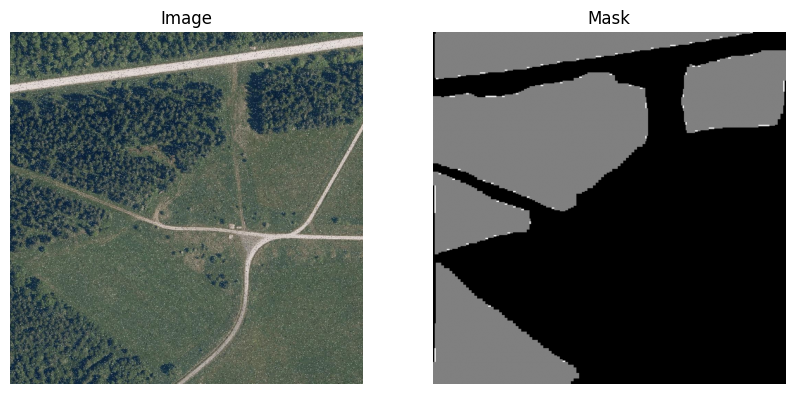

In [ ]:
import matplotlib.pyplot as plt

img_name = os.listdir("/content/vegetation-segmentation-4/train/images")[0]

img = Image.open(f"/content/vegetation-segmentation-4/train/images/{img_name}")
mask = Image.open(f"/content/vegetation-segmentation-4/train/masks/{img_name}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Image")
plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.axis("off"); plt.title("Mask")
plt.show()


In [ ]:
import os

print("Train images:", os.listdir('/content/vegetation-segmentation-4/train/images')[:3])
print("Train masks:", os.listdir('/content/vegetation-segmentation-4/train/masks')[:3])


Train images: ['1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg', '0-21-40_png.rf.972a184968d45f83d6bb9b51d7747f82.jpg', '0-65-53_png.rf.a9eab6cd2cc811613a6a9121a5408f7b.jpg']
Train masks: ['1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg', '0-21-40_png.rf.972a184968d45f83d6bb9b51d7747f82.jpg', '0-65-53_png.rf.a9eab6cd2cc811613a6a9121a5408f7b.jpg']


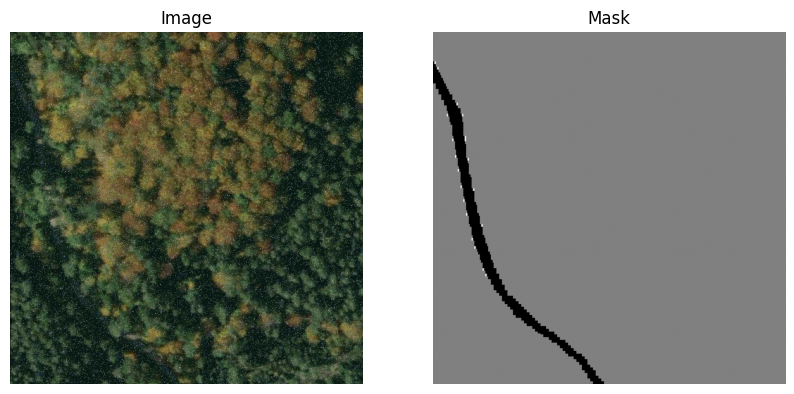

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img_name = os.listdir("/content/vegetation-segmentation-4/train")[0]

img = Image.open(f"/content/vegetation-segmentation-4/train/images/0-0-0_png.rf.fa6e717479576f1d9c46542752eb7567.jpg")
mask = Image.open(f"/content/vegetation-segmentation-4/train/masks/0-0-0_png.rf.fa6e717479576f1d9c46542752eb7567.jpg")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()


In [ ]:
!pip install segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.images = os.listdir(images_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = np.array(Image.open(f"{self.images_dir}/{img_name}").convert("RGB"))
        mask = np.array(Image.open(f"{self.masks_dir}/{img_name}").convert("L"))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

train_tf = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

train_ds = SegmentationDataset(
    "/content/vegetation-segmentation-4/train/images",
    "/content/vegetation-segmentation-4/train/masks",
    train_tf
)

val_ds = SegmentationDataset(
    "/content/vegetation-segmentation-4/valid/images",
    "/content/vegetation-segmentation-4/valid/masks",
    val_tf
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2  # vegetation + background
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
import os
import numpy as np
from PIL import Image

mask_dir = "/content/vegetation-segmentation-4/train/masks"
mask_file = os.listdir(mask_dir)[0]

mask_path = os.path.join(mask_dir, mask_file)
mask = np.array(Image.open(mask_path))

print("Mask file:", mask_file)
print("Unique values in mask:", np.unique(mask))


Mask file: 1-12-20_png.rf.70e7ba302490da372a77a9ffbb622f31.jpg
Unique values in mask: [0 1 2]


In [ ]:
epochs = 25

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import torch

imgs, masks = next(iter(train_loader))

print("Images shape:", imgs.shape)
print("Masks shape:", masks.shape)
print("Masks dtype:", masks.dtype)
print("Unique mask values:", torch.unique(masks))


Images shape: torch.Size([8, 3, 256, 256])
Masks shape: torch.Size([8, 256, 256])
Masks dtype: torch.int64
Unique mask values: tensor([0, 1, 2])


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8m.pt")

model.train(
    data="/content/vegetation-segmentation-4/data.yaml",
    epochs=150,
    imgsz=640,
    batch=8,      # reduce for memory
    device=0,

    mosaic=1.0,
    mixup=0.2,
    fliplr=0.5,
    scale=0.5
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vegetation-segmentation-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d55d2e29820>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!yolo task=segment mode=train \
model=yolov8s.pt \
data="/content/vegetation-segmentation-4/data.yaml" \
epochs=100 \
imgsz=640 \
batch=16 \
optimizer=AdamW \
lr0=0.001 \
patience=20 \
name=train


WARNING ⚠️ conflicting 'task=segment' passed with 'task=detect' model. Ignoring 'task=segment' and updating to 'task=detect' to match model.
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vegetation-segmentation-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mul

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8s-seg.pt")

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt# Load your vegetation model
model = YOLO("/content/runs/segment/train/weights/best.pt")   # <-- update path if needed

# Evaluate
metrics = model.val()

# Extract metrics
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)']
map5095 = metrics.results_dict['metrics/mAP50-95(B)']

# Calculate simple accuracy
accuracy = (precision + recall) / 2

# Print results
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("mAP50:", round(map50, 4))
print("mAP50-95:", round(map5095, 4))
print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")
plt.figure(figsize=(6, 5))
plt.bar(["Accuracy"], [accuracy])
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.ylim(0, 1)
plt.show()